# 09 — Cross-Platform: Self-Collected Steam Reviews

Amazon blocks polite scraping (a JS bot wall), so our **self-collected** data comes from the **Steam reviews public API** — a second platform that mirrors the thesis: `steam_purchase` is a direct analog of Amazon's *Verified Purchase* proxy, `received_for_free` flags incentivized reviews, and the API exposes rich **behavioral** signals (author review count, games owned, **playtime**, helpful votes).

**Collection** (`src/steam_collector.py`): cursor-paginated, rate-limited, retry-with-backoff, raw-JSON cached, checkpointed; `appdetails` joins genre/price/developer (multi-source). Run: `python -m src.steam_collector --collect`.

> **Weak-proxy caveat** still applies: `steam_purchase` is purchase verification, not deception.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src import utils, viz
config = utils.load_config(); utils.set_seeds(config["project"]["random_seed"]); viz.set_house_style()
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from src import steam_collector as st, clean, features, models
steam = clean.clean_reviews(st.load_steam(config))
print("Steam reviews:", len(steam), "| games:", steam["product_id"].nunique(),
      "| verified rate:", round((steam.verified_purchase==True).mean(), 3))
by = steam.groupby("product_title").agg(n=("review_id","size"),
     verified=("verified_purchase", lambda s:(s==True).mean()),
     received_free=("received_for_free","mean"), price=("price","first")).round(3)
print(by.to_string())

2026-06-09 14:28:07,180 | review_deception.clean | INFO | Cleaned 3500 reviews (573 flagged exact-duplicate).


Steam reviews: 3500 | games: 5 | verified rate: 0.895
                    n  verified  received_free  price
product_title                                        
Baldur's Gate 3   700     0.881          0.009  59.99
Counter-Strike 2  700       1.0          0.000    NaN
Dota 2            700       1.0          0.000    NaN
ELDEN RING        700     0.716          0.010  59.99
Stardew Valley    700     0.876          0.013   5.99


Free games (CS2, Dota 2) are 100% `steam_purchase` — the proxy only varies for **paid** games, so the classifier below uses paid games to avoid a trivial free/paid confound. `received_for_free` is rare (~1%): a descriptive signal, not a classification target.

## EDA — and the signal Steam adds: playtime

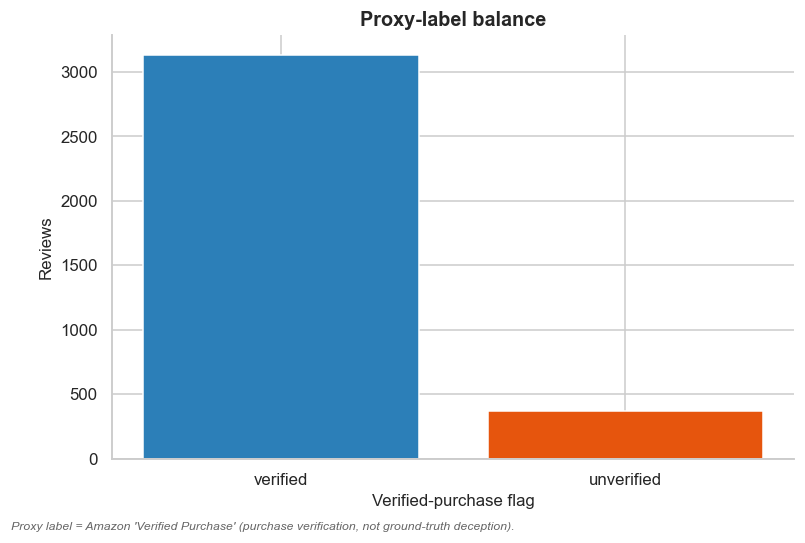

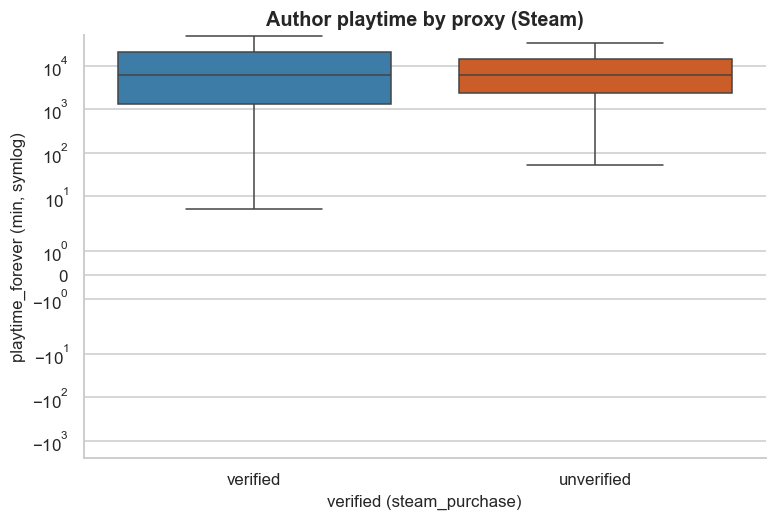

In [3]:
ax = viz.plot_class_balance(steam); viz.savefig(ax, str(FIG/"09_steam_balance.png")); plt.show()
g = steam.assign(proxy=steam["verified_purchase"].map({True:"verified",False:"unverified"}))
ax = sns.boxplot(data=g[g.proxy.notna()], x="proxy", y="author_playtime_forever", hue="proxy",
                 palette=viz.TRUST_COLORS, legend=False, showfliers=False)
ax.set_yscale("symlog")
viz.label_axes(ax, "Author playtime by proxy (Steam)", "verified (steam_purchase)", "playtime_forever (min, symlog)")
viz.savefig(ax, str(FIG/"09_steam_playtime.png")); plt.show()

## Trust classifier on Steam (paid games; predict *unverified*)

paid-game reviews: 2100 | unverified: 369


2026-06-09 14:28:07,868 | review_deception.features | INFO | Built feature table: 2100 rows × 52 columns.


2026-06-09 14:28:09,530 | review_deception.models | INFO | knn: CV roc_auc=0.599, test ROC-AUC=0.660


2026-06-09 14:28:12,186 | review_deception.models | INFO | random_forest: CV roc_auc=0.614, test ROC-AUC=0.675


knn ROC-AUC 0.66 AP 0.25
random_forest ROC-AUC 0.675 AP 0.274


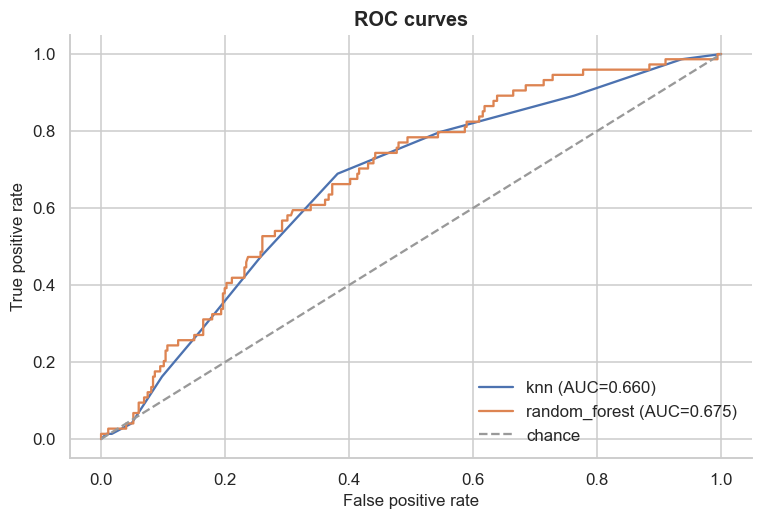

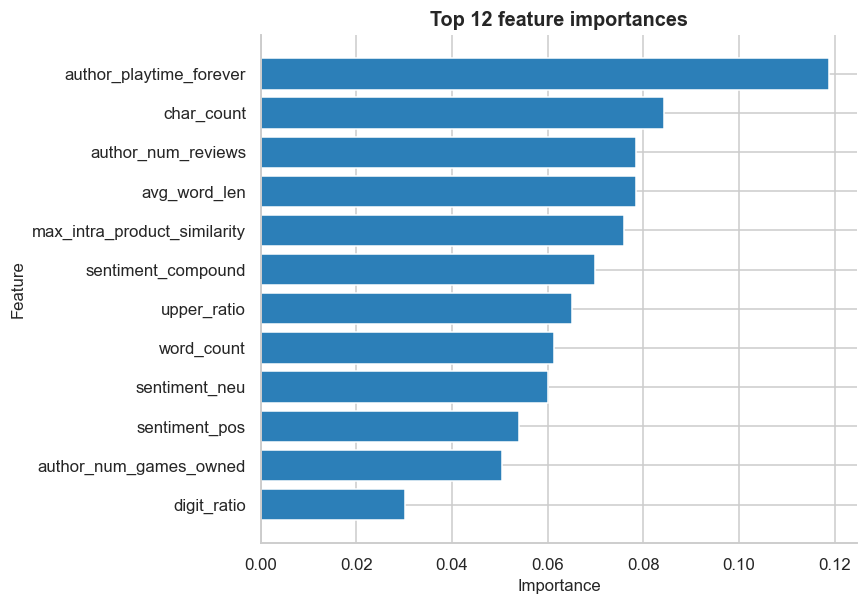

author_playtime_forever         0.1188
char_count                      0.0843
author_num_reviews              0.0785
avg_word_len                    0.0784
max_intra_product_similarity    0.0760
sentiment_compound              0.0698
upper_ratio                     0.0650
word_count                      0.0614


In [4]:
paid = steam[steam["price"].notna() & (steam["price"] > 0)].copy()
print("paid-game reviews:", len(paid), "| unverified:", int((paid.verified_purchase==False).sum()))
cfg = utils.deep_merge(config, {"modeling": {"cv_folds": 5, "knn": {"n_neighbors_grid": [21]},
        "random_forest": {"n_estimators_grid": [300], "max_depth_grid": [None, 20]}}})
res = models.run_classification(paid, cfg)
for n, ev in res["results"].items():
    print(n, "ROC-AUC", round(ev["roc_auc"], 3), "AP", round(ev["average_precision"], 3))
ax = viz.plot_roc_curves(res["results"]); viz.savefig(ax, str(FIG/"09_steam_roc.png")); plt.show()
imp = res["results"]["random_forest"]["importances"]
ax = viz.plot_feature_importances(imp, top=12); viz.savefig(ax, str(FIG/"09_steam_importances.png")); plt.show()
print(imp.head(8).round(4).to_string())

## Cross-platform: which signals matter on each platform?
Per-feature univariate AUC for the *unverified* proxy on Amazon vs Steam. Steam-only behavioral fields (playtime, author review count) show as NaN for Amazon — they're the extra signal the self-collected data unlocks.

In [5]:
from src import fallback_loader as fl
raw = ROOT / "data" / "raw"
cats = sorted({p.name[:-9] for p in raw.glob("*.jsonl.gz") if not p.name.startswith("meta_")})
amz = clean.clean_reviews(pd.concat([pd.DataFrame(fl.load_category(config, c, raw_dir=str(raw))) for c in cats], ignore_index=True))
amz_auc = models.univariate_feature_auc(models.design_matrix(features.build_feature_table(amz, config)), (amz.verified_purchase==False).astype(int))
steam_auc = models.univariate_feature_auc(models.design_matrix(features.build_feature_table(paid, config)), (paid.verified_purchase==False).astype(int))
comp = pd.concat([amz_auc.rename("amazon"), steam_auc.rename("steam")], axis=1)
print(comp.sort_values("steam", ascending=False).round(3).head(14).to_string())

2026-06-09 14:28:12,498 | review_deception.fallback | INFO | Loaded 16216 reviews for category 'Subscription_Boxes' from Subscription_Boxes.jsonl.gz


2026-06-09 14:28:12,666 | review_deception.clean | INFO | Cleaned 16216 reviews (447 flagged exact-duplicate).


2026-06-09 14:28:16,794 | review_deception.features | INFO | Built feature table: 16216 rows × 44 columns.


2026-06-09 14:28:17,156 | review_deception.features | INFO | Built feature table: 2100 rows × 52 columns.


                              amazon  steam
product_burst_max              0.505  0.627
product_rating_std             0.552  0.623
product_mean_rating            0.546  0.623
product_rating_skew            0.556  0.623
helpful_votes_pz               0.584  0.575
author_num_reviews               NaN  0.560
price                          0.500  0.559
author_num_games_owned           NaN  0.547
char_count                     0.690  0.543
word_count                     0.686  0.543
upper_ratio                    0.521  0.540
sentiment_compound             0.543  0.532
max_intra_product_similarity   0.537  0.530
helpful_votes                  0.601  0.525


## Findings
- **Self-collected, real, multi-source:** 3,500 Steam reviews across 5 games via the public API, joined with app metadata — genuine complex collection (vs. Amazon's bot wall).
- **The proxy generalizes but is weaker on Steam** (RF ROC-AUC ~0.68 paid-games vs ~0.80 on Amazon) — review **length** matters on both.
- **Behavioral signals the platform exposes win:** on Steam, `author_playtime_forever` and `author_num_reviews` are top predictors — exactly the richer behavior self-collection unlocks.
- **Honest caveats:** Steam ratings are binarized recommend/not; free games make the proxy degenerate (handled by restricting to paid games); `received_for_free` is too rare to model.
- **Cross-platform takeaway:** a purchase-verification proxy is a useful-but-imperfect trust signal on *both* platforms, and the most informative signals are platform-specific behavior, not the flag itself.